# Project lattice paths in order parameters space




In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

# from utils_analysis_mf import *


main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils
sys.path.append(main_path + "covid/")
sys.path.append(main_path + "lattice/")
os.chdir(main_path + "mean_field_theory/")
from utils_mean_field import *
from script_mean_field_covid import *
os.chdir('../lattice')



e:\ESCAPE_PATHS\lattice\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\lattice\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights
C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Loaded 29 KD vectors


# Read results

# PATH CONSTANTS

In [2]:
PROTEIN_INIT = Proteins_utils.load_FASTA(
        "../lattice/msa/output_msa_structure_0_beta_1000.fasta"
    )[0]  # Load the protein sequence from the FASTA file.

sites = np.array([9, 10, 11, 12, 13, 16, 17, 25, 26]) - 1
print("sites upper face", sites)
w_bias = np.zeros((PROTEIN_INIT.shape[0], 20, 1))
for site in sites:
    wt_aa = PROTEIN_INIT[site]
    print("wt_aa", Proteins_utils.num2seq(np.array([wt_aa])))
    # put a 1 everywhere except for the wt_aa
    for i in range(20):
        if i != wt_aa:
            w_bias[site, i, 0] = 1 
            

sites upper face [ 8  9 10 11 12 15 16 24 25]
wt_aa D
wt_aa E
wt_aa Y
wt_aa Q
wt_aa G
wt_aa P
wt_aa K
wt_aa K
wt_aa K


In [3]:
RBM = RBM_utils.loadRBM("rbm/RBM_structure_0_beta_1000")

wgamma = np.transpose(RBM.weights[:, :, :], (1, 2, 0))
#concat bias
wgamma = np.concatenate((wgamma, w_bias), axis=2)

wgamma.shape#L, Q, M
#reshape to (M, L*Q)
wgamma_flat= wgamma.reshape(wgamma.shape[0]*wgamma.shape[1], wgamma.shape[2]).T

wgamma_flat.shape

(21, 540)

# Gisaid sequences

# Get order parameters

In [4]:

#find the 2 hidden units with highest variance and decorrekated



In [5]:
def project_without_blas(one_hot_seqs, wgamma_flat):
    """
    Project each of N sequences (length-D) onto each of K axes,
    without calling the BLAS-backed dot() function.
    Returns an (N, K) array of projections.
    """
    N, D = one_hot_seqs.shape
    K, D2 = wgamma_flat.shape
    

    assert D == D2
    
    # pre-allocate output
    projections = np.empty((N, K), dtype=one_hot_seqs.dtype)
    
    # for each axis, multiply elementwise and sum
    for k in range(K):
        # Broadcast: (N, D) * (D,) → (N, D), then sum over D → (N,)
        projections[:, k] = (one_hot_seqs * wgamma_flat[k]).sum(axis=1)
    
    return projections


# Get MCMC paths

In [6]:
def get_mcmc_proba_aa(dir,wgamma_flat):
    paths_nb=100
    proj_mat=[]
    for path_no in range(paths_nb):
        fasta_file = os.path.join(dir, f"output_{path_no}.fasta")
        if not os.path.exists(fasta_file):
            print('not found')
            continue
        sequences = Proteins_utils.load_FASTA(fasta_file, drop_duplicates=False)
        one_hot_seqs = np.array([one_hot_encode_concat(seq) for seq in sequences])
        projs= project_without_blas(one_hot_seqs, wgamma_flat)
        proj_mat.append(projs)
    proj_mat= np.array(proj_mat)
    #mean around axis 0
    print("proj_mat", proj_mat.shape)
    return proj_mat

#remove duplicates paths


In [7]:

seqs=Proteins_utils.load_FASTA('../lattice/msa/output_msa_structure_0_beta_1000.fasta')
one_hot_seqs=np.array([one_hot_encode_concat(seq) for seq in seqs])

one_hot_seqs.shape

(199, 540)

# Project




In [8]:
L=27
beta_w=1

folder='../mean_field_theory/results_scripts/lattice/mean_f_lattice_T_6_beta_w_'+str(beta_w)+'_beta_phi_1'
mopt = -np.load(f"{folder}/mopt.npy")*L 
mopt.shape#(T, M) path of T steps and M hidden units
var = np.var(mopt[:,:-1], axis=0)
idx = np.argsort(var)[:]#indices of the 1 hidden units with
#project mopt on these 2 hidden units
import numpy as np
#idx and last one
idx=np.array([mopt.shape[1]-1,idx[-1]])
mopt_2d = mopt[:, idx]
print("idx", idx)

dir_mcmc = f"../lattice/paths/w_upper_T6_beta_w_{beta_w}"
paths_mcmc=-get_mcmc_proba_aa(dir_mcmc, wgamma_flat)
paths_mcmc.shape#(num_paths, T, M)

idx [20 12]
proj_mat (100, 7, 21)


(100, 7, 21)

explained variance ratio [0.97706806 0.01822713]
random_idxs [21, 53, 88, 81, 36]


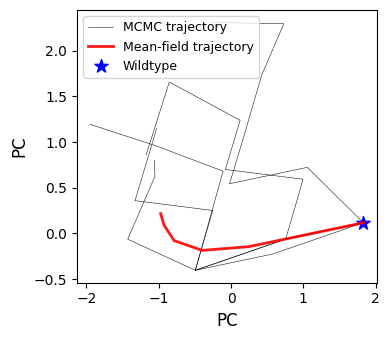

In [9]:
def project_and_plot_2d():




    # --- Project reference points and trajectories ---

    from sklearn.decomposition import PCA
    pca = PCA(n_components=2, svd_solver="full", random_state=0)
    pca.fit(mopt)  # fit only on mean-field trajectory (excluding final point)
    print("explained variance ratio", pca.explained_variance_ratio_)
    mopt_2d = pca.transform(mopt)
    paths_mcmc_2d = pca.transform(paths_mcmc.reshape(-1, paths_mcmc.shape[2])).reshape(paths_mcmc.shape[0], paths_mcmc.shape[1], 2)
    #ranomly select 5 MCMC trajectories to plot
    import random
    random.seed(21)  # for reproducibility
    random_idxs = random.sample(range(len(paths_mcmc)), 5)
    print("random_idxs", random_idxs)
    paths_mcmc_2d = paths_mcmc_2d[random_idxs]


    wt_2d = paths_mcmc_2d[0]

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(4, 3.5))

    # Scatter of observed sequences


    # --- MCMC trajectories in thick black lines (only one label) ---
    for i, path in enumerate(paths_mcmc_2d):
        label = "MCMC trajectory" if i == 0 else None
        ax.plot(path[:, 0], path[:, 1],
                color='black', linewidth=0.4, alpha=0.9,
                label=label)
        
    #plot mopt2D
    ax.plot(mopt_2d[:,0], mopt_2d[:,1],
            color='red', linewidth=2, alpha=0.9,
            label="Mean-field trajectory")

    # --- VOC stars and annotations ---


    # --- Wildtype star ---
    ax.scatter(wt_2d[0, 0], wt_2d[0, 1], color='blue', marker='*', s=100, label='Wildtype')

    # --- Labels and colorbar ---
    ax.set_ylabel("PC", fontsize=12)
    ax.set_xlabel("PC", fontsize=12)



    ax.legend(loc='best', frameon=True, fontsize=9)

    # --- PRL-style black frame ---
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

    plt.tight_layout()
    plt.show()

project_and_plot_2d()


random_idxs [21, 53, 88, 81, 36]


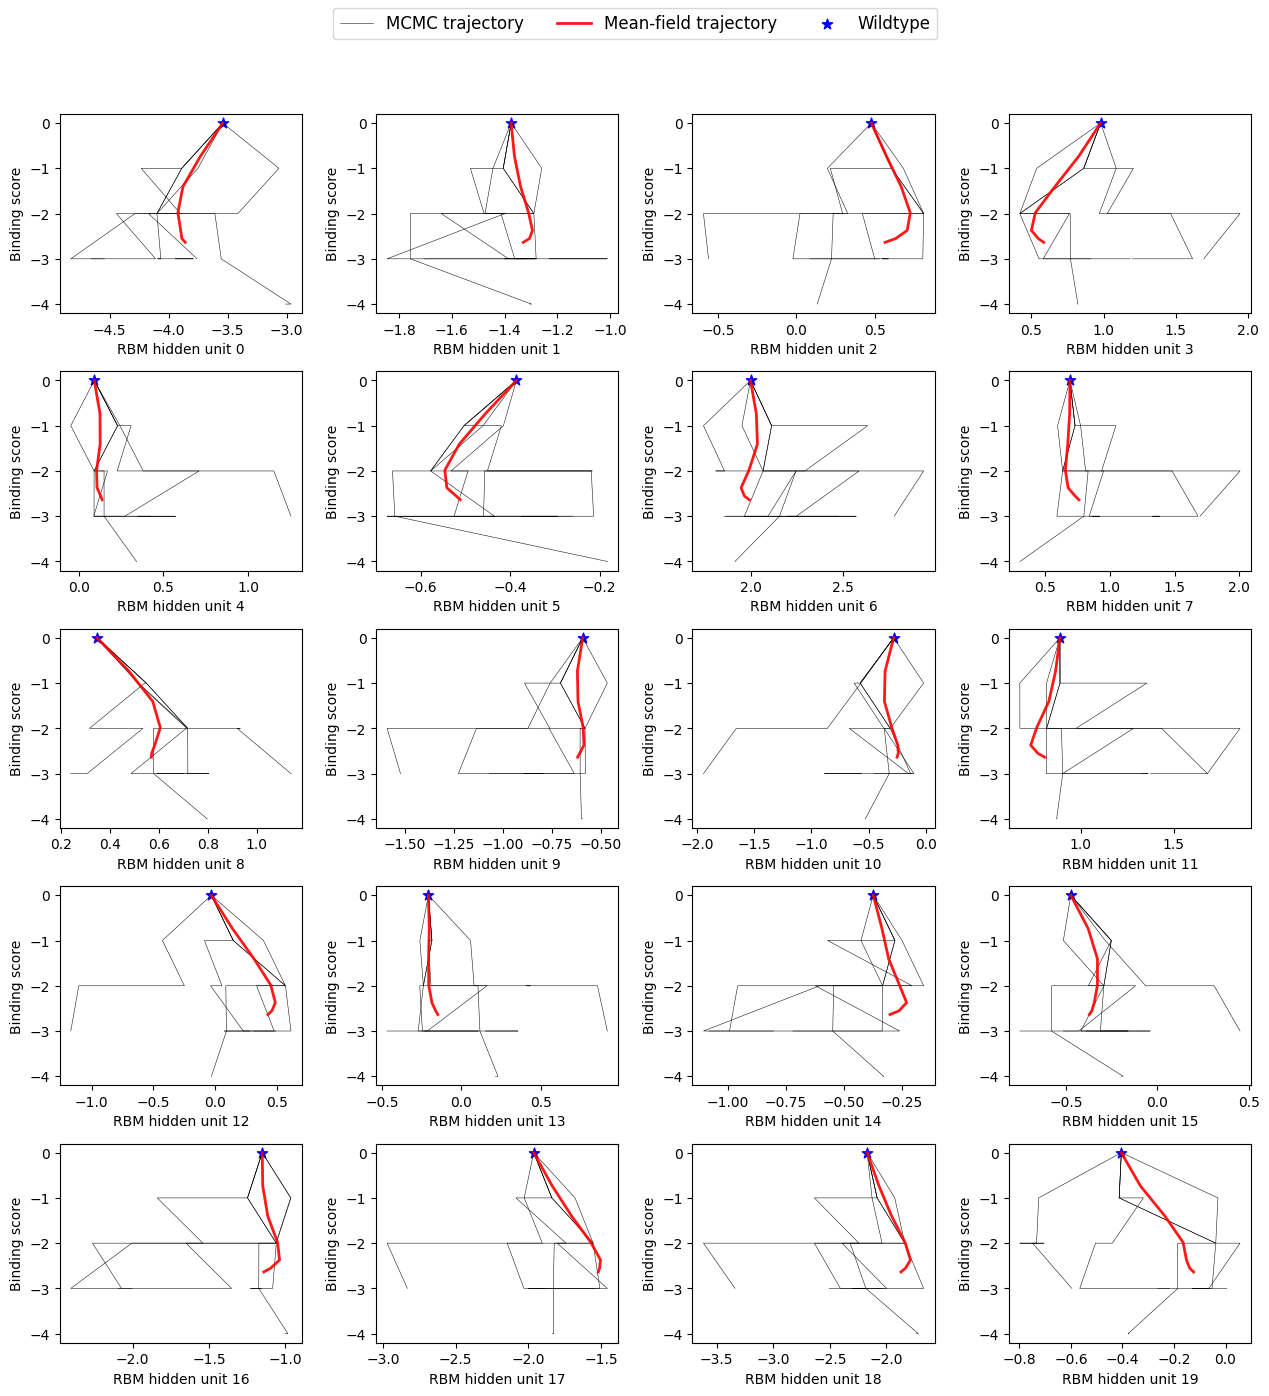

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random

def project_and_plot_2d(n_random_paths=5, seed=21, ncols=4, js=None):
    """
    Plots subplots for each j in js:
      x-axis = coordinate j
      y-axis = last coordinate (index D-1)
    Expects global arrays:
      - mopt:          shape (T+1, D)
      - paths_mcmc:    shape (N_paths, T+1, D)
    """
    assert mopt.ndim == 2 and paths_mcmc.ndim == 3, "mopt (T,D), paths_mcmc (N,T,D)"
    T, D = mopt.shape
    last_idx = D - 1
    if js is None:
        js = [j for j in range(D) if j != last_idx]  # all except last

    # Randomly select MCMC trajectories to plot
    random.seed(seed)
    N = paths_mcmc.shape[0]
    n_pick = min(n_random_paths, N)
    random_idxs = random.sample(range(N), n_pick)
    print("random_idxs", random_idxs)

    # Use the first selected path's first point as "wildtype"
    wt = paths_mcmc[random_idxs[0], 0]  # shape (D,)

    # --- Layout ---
    nplots = len(js)
    nrows = math.ceil(nplots / ncols)
    figsize = (3.2 * ncols, 2.8 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    # For a single shared legend later
    handled_legend = False

    for k, j in enumerate(js):
        ax = axes[k]

        # MCMC trajectories (thin black)
        for i, pidx in enumerate(random_idxs):
            path = paths_mcmc[pidx]  # (T+1, D)
            lbl = "MCMC trajectory" if (i == 0 and not handled_legend) else None
            ax.plot(path[:, j], path[:, last_idx],
                    color='black', linewidth=0.4, alpha=0.9, label=lbl)

        # Mean-field trajectory (thick red)
        lbl = "Mean-field trajectory" if not handled_legend else None
        ax.plot(mopt[:, j], mopt[:, last_idx],
                color='red', linewidth=2, alpha=0.9, label=lbl)

        # Wildtype star (blue)
        lbl = "Wildtype" if not handled_legend else None
        ax.scatter(wt[j], wt[last_idx], color='blue', marker='*', s=60, label=lbl)

        ax.set_xlabel(f"RBM hidden unit {j}")
        ax.set_ylabel("Binding score")
        # ax.set_title(f"Unit {last_idx} vs Unit {j}", fontsize=9)

        # PRL-style black frame, no grid
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(0.8)

        if not handled_legend:
            handled_legend = True

    # Hide any unused axes
    for k in range(nplots, len(axes)):
        axes[k].axis('off')

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=3, frameon=True, fontsize=12)

    plt.tight_layout(rect=(0, 0, 1, 0.93))  # leave space for shared legend
    plt.show()

# Call it:
project_and_plot_2d()


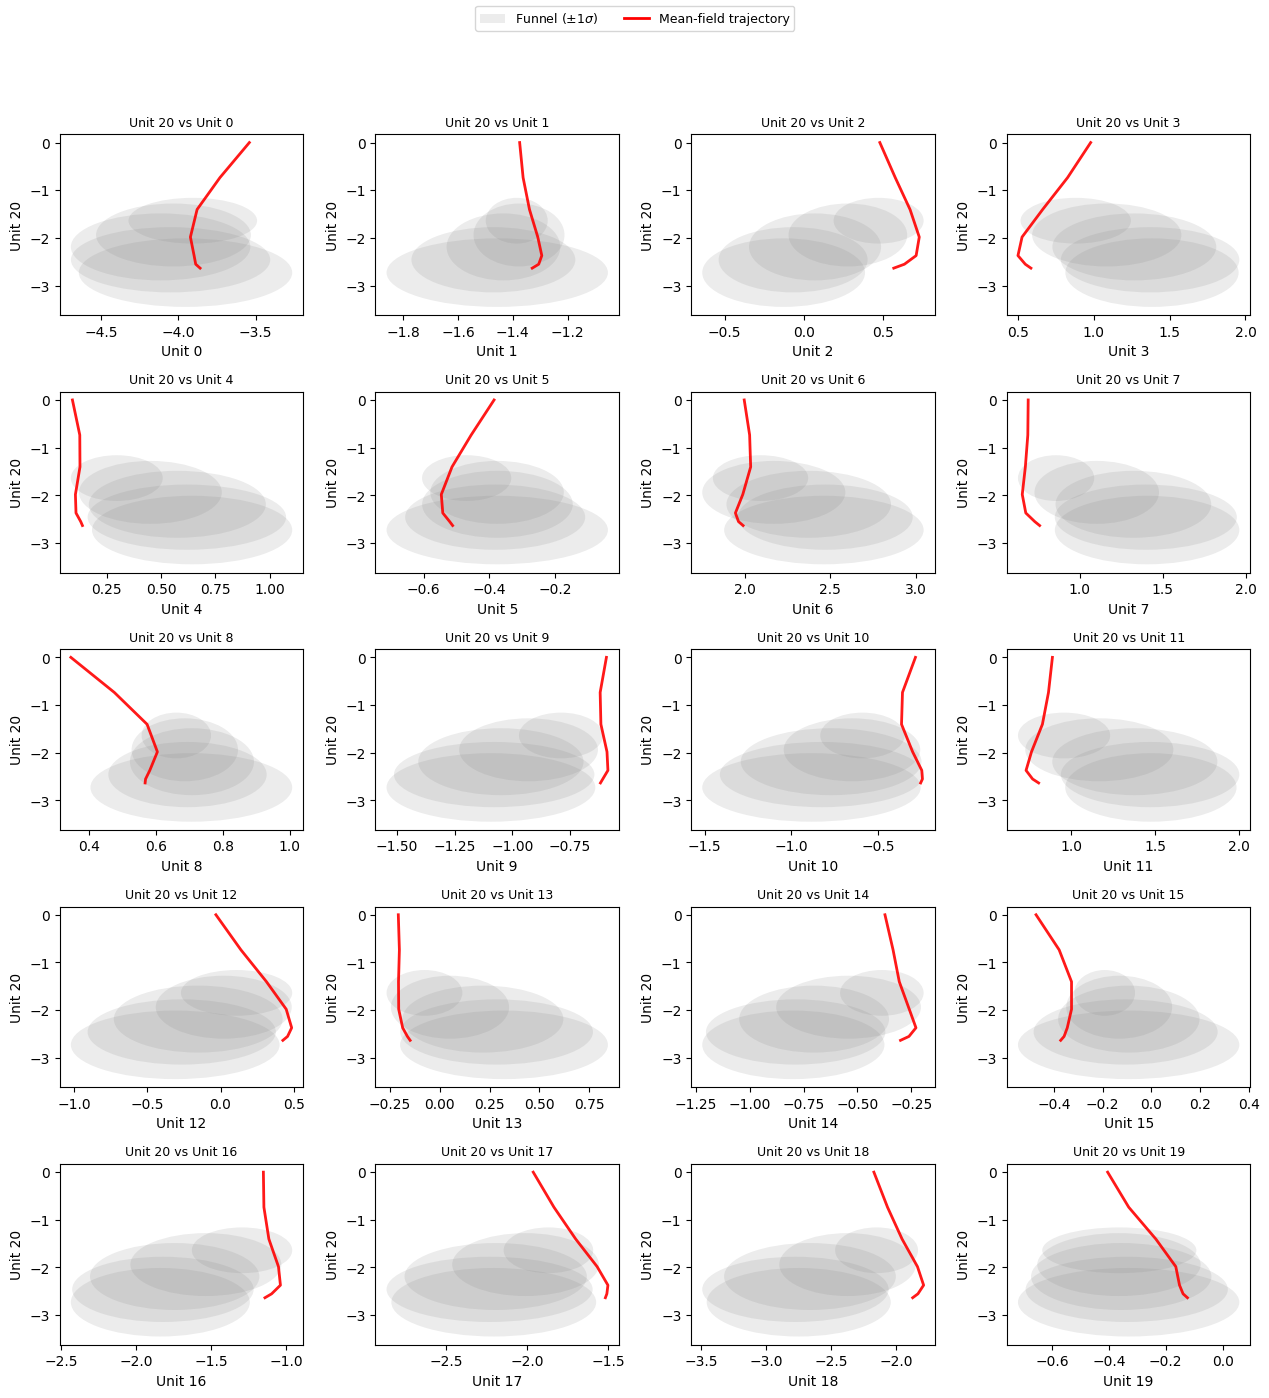

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Ellipse, Patch
from matplotlib.lines import Line2D

def plot_funnel_per_unit(ncols=4, js=None, step_stride=1, std_scale=1.0, ellipse_alpha=0.15):
    """
    For each unit j, plot (x_j, x_{D-1}) with:
      - Shaded axis-aligned ellipses per time step t representing ± std on x and y across MCMC paths
      - Mean-field trajectory (mopt) as a red line

    Expects:
      mopt:        (T+1, D)
      paths_mcmc:  (N_paths, T+1, D)

    Parameters:
      ncols:          grid columns
      js:             list of unit indices to plot on x-axis (default: all except D-1)
      step_stride:    plot every 'step_stride' time steps to reduce clutter
      std_scale:      multiply std by this factor (e.g., 2.0 for ±2σ)
      ellipse_alpha:  transparency of the funnel ellipses
    """
    assert mopt.ndim == 2 and paths_mcmc.ndim == 3, "mopt (T+1,D), paths_mcmc (N,T+1,D)"
    T1, D = mopt.shape
    last_idx = D - 1
    if js is None:
        js = [j for j in range(D) if j != last_idx]

    nplots = len(js)
    nrows = math.ceil(nplots / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.8*nrows), squeeze=False)
    axes = axes.ravel()

    for k, j in enumerate(js):
        ax = axes[k]

        # Funnel: one ellipse per time step
        for t in range(0, T1, step_stride):
            xs = paths_mcmc[:, t, j]
            ys = paths_mcmc[:, t, last_idx]
            mu_x = xs.mean()
            mu_y = ys.mean()
            std_x = xs.std(ddof=0)
            std_y = ys.std(ddof=0)

            e = Ellipse(
                (mu_x, mu_y),
                width=2 * std_scale * std_x,
                height=2 * std_scale * std_y,
                angle=0.0,
                facecolor="gray",
                edgecolor="none",
                alpha=ellipse_alpha,
                zorder=1,
            )
            ax.add_patch(e)

        # Mean-field trajectory
        ax.plot(
            mopt[:, j], mopt[:, last_idx],
            color="red", linewidth=2, alpha=0.9,
            label="Mean-field trajectory" if k == 0 else None,
            zorder=2,
        )

        ax.set_xlabel(f"Unit {j}")
        ax.set_ylabel(f"Unit {last_idx}")
        ax.set_title(f"Unit {last_idx} vs Unit {j}", fontsize=9)

        # PRL-style black frame
        for spine in ax.spines.values():
            spine.set_edgecolor("black")
            spine.set_linewidth(0.8)

    # Hide any unused axes
    for k in range(nplots, len(axes)):
        axes[k].axis("off")

    # Shared legend (one entry for ellipses + mean-field line)
    proxy_ellipse = Patch(facecolor="gray", alpha=ellipse_alpha, label=r"Funnel ($\pm 1\sigma$)")
    proxy_line = Line2D([0], [0], color="red", lw=2, label="Mean-field trajectory")
    fig.legend([proxy_ellipse, proxy_line],
               [r"Funnel ($\pm 1\sigma$)", "Mean-field trajectory"],
               loc="upper center", ncol=2, frameon=True, fontsize=9)

    plt.tight_layout(rect=(0, 0, 1, 0.93))
    plt.show()

# Example:
plot_funnel_per_unit(ncols=4, js=None, step_stride=1, std_scale=1.0, ellipse_alpha=0.15)


random_idxs [21, 53, 88, 81, 36]


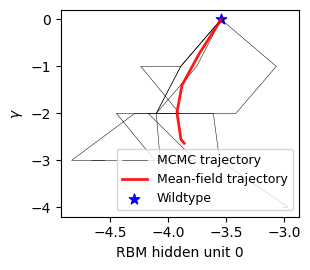

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import random

def project_and_plot_first_only(n_random_paths=5, seed=21, js=None):
    """
    Single-panel version of project_and_plot_2d:
      x-axis = coordinate j0 (first j in js or first non-last unit)
      y-axis = last coordinate (index D-1)
    Expects global arrays:
      - mopt:          shape (T+1, D)
      - paths_mcmc:    shape (N_paths, T+1, D)
    """
    assert mopt.ndim == 2 and paths_mcmc.ndim == 3, "mopt (T+1,D), paths_mcmc (N,T+1,D)"
    T1, D = mopt.shape
    last_idx = D - 1

    # default js: all except last; take the first one
    if js is None:
        js = [j for j in range(D) if j != last_idx]
    assert len(js) > 0, "No valid j to plot (D must be >= 2)."
    j0 = js[0]

    # Randomly select MCMC trajectories to plot
    random.seed(seed)
    N = paths_mcmc.shape[0]
    n_pick = min(n_random_paths, N)
    random_idxs = random.sample(range(N), n_pick)
    print("random_idxs", random_idxs)

    # Use the first selected path's first point as "wildtype"
    wt = paths_mcmc[random_idxs[0], 0]  # shape (D,)

    # --- Single panel ---
    fig, ax = plt.subplots(figsize=(3.2, 2.8))

    # MCMC trajectories (thin black)
    for i, pidx in enumerate(random_idxs):
        path = paths_mcmc[pidx]  # (T+1, D)
        lbl = "MCMC trajectory" if i == 0 else None
        ax.plot(path[:, j0], path[:, last_idx],
                color='black', linewidth=0.4, alpha=0.9, label=lbl)

    # Mean-field trajectory (thick red)
    ax.plot(mopt[:, j0], mopt[:, last_idx],
            color='red', linewidth=2, alpha=0.9, label="Mean-field trajectory")

    # Wildtype star (blue)
    ax.scatter(wt[j0], wt[last_idx], color='blue', marker='*', s=60, label='Wildtype')

    ax.set_xlabel(f"RBM hidden unit {j0}")
    ax.set_ylabel(r"$\gamma$")

    # PRL-style black frame, no grid
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

    ax.legend(loc='best', frameon=True, fontsize=9)

    plt.tight_layout()
    plt.show()

# Call it:
project_and_plot_first_only()


In [13]:
idx

array([20, 12], dtype=int64)

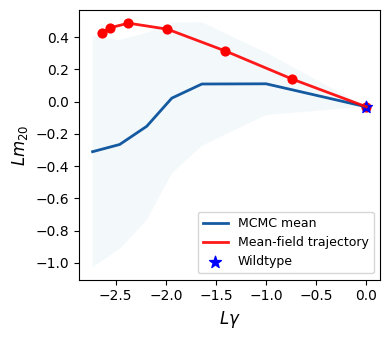

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

def _make_band_polygon(xs_lower, ys_lower, xs_upper, ys_upper):
    """
    Build a closed polygon between two parametric curves:
      lower: (xs_lower[t], ys_lower[t])
      upper: (xs_upper[t], ys_upper[t])
    Curves are connected forward for lower and backward for upper.
    """
    pts_lower = np.column_stack([xs_lower, ys_lower])          # T x 2
    pts_upper = np.column_stack([xs_upper, ys_upper])[::-1, :] # T x 2 (reversed)
    pts = np.vstack([pts_lower, pts_upper])
    return Polygon(pts, closed=True, linewidth=0)

def project_and_plot_2d(*, band_alpha_xy=(0.18, 0.12),
                        band_color_x="#3182bd", band_color_y="#9ecae1",
                        mean_color="#08519c", mean_lw=2.0):
    """
    Plot 2D mean MCMC trajectory with shaded m±std ribbons
    (component-wise) and the provided mean-field trajectory mopt_2d.

    Expected globals:
        - paths_mcmc: list of arrays with shape (T, S), we use [:, idx] -> (T,2)
        - mopt_2d: array (T,2)
        - idx: tuple/list of two indices selecting the 2D projection
    """

    # ---- Stack MCMC trajectories to (N, T, 2) ----
    paths_mcmc_2d = [p[:, idx] for p in paths_mcmc]  # each: (T, 2)
    assert len(paths_mcmc_2d) > 0, "No MCMC paths."
    P = np.stack(paths_mcmc_2d, axis=0)              # (N, T, 2)
    N, T, _ = P.shape

    # ---- Mean and std per step ----
    mean_path = P.mean(axis=0)                       # (T, 2): [mx(t), my(t)]
    std_path  = P.std(axis=0, ddof=1 if N > 1 else 0)  # (T, 2): [sx(t), sy(t)]

    mx, my = mean_path[:, 0], mean_path[:, 1]
    sx, sy = std_path[:, 0],  std_path[:, 1]

    # ---- Build shaded ribbons (2D) ----
    # Vertical band: y in [my - sy, my + sy] at x = mx
    poly_y = _make_band_polygon(
        xs_lower=mx, ys_lower=my - sy,
        xs_upper=mx, ys_upper=my + sy
    )

    # Horizontal band: x in [mx - sx, mx + sx] at y = my
    poly_x = _make_band_polygon(
        xs_lower=mx - sx, ys_lower=my,
        xs_upper=mx + sx, ys_upper=my
    )

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(4, 3.5))

    # Add bands (draw y-band first, then x-band)
    poly_y.set_facecolor(band_color_y)
    poly_y.set_alpha(band_alpha_xy[1])
    ax.add_patch(poly_y)

    poly_x.set_facecolor(band_color_x)
    poly_x.set_alpha(band_alpha_xy[0])
    # ax.add_patch(poly_x)

    # Mean MCMC trajectory
    ax.plot(mx, my, color=mean_color, linewidth=mean_lw, alpha=0.95, label="MCMC mean")

    # Mean-field trajectory
    ax.plot(mopt_2d[:, 0], mopt_2d[:, 1],
            color='red', linewidth=2.0, alpha=0.9,
            label="Mean-field trajectory")
    ax.scatter(mopt_2d[:, 0], mopt_2d[:, 1], color='red', marker='o', s=40)  # start

    # Wildtype star (first step of first path)
    wt_2d = P[0, 0, :]
    ax.scatter(wt_2d[0], wt_2d[1], color='blue', marker='*', s=80, label='Wildtype')

    # Labels
    ax.set_ylabel(r"$L m_{" + str(idx[0]) + "}$", fontsize=12)
    ax.set_xlabel(r"$L \gamma$", fontsize=12)

    # Legend
    ax.legend(loc='best', frameon=True, fontsize=9)

    # PRL-style black frame, no grid
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

    plt.tight_layout()
    plt.show()

project_and_plot_2d()


In [15]:
idx

array([20, 12], dtype=int64)

In [16]:
path_proba = '../mean_field_theory/results_scripts/lattice/mean_f_lattice_T_6_beta_w_1_beta_phi_1.npy'
probas = np.load(path_proba)  # shape: (amino_acid, step, site)
#round to cloestes 10^4
probas = np.round(probas, 6)  # Round to 4 decimal places

In [17]:
import numpy as np


# (1) Ensure each (step, site) column is a valid distribution
probas = probas / probas.sum(axis=0, keepdims=True)



C:\Users\maria\AppData\Local\Temp\ipykernel_34268\4116176787.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


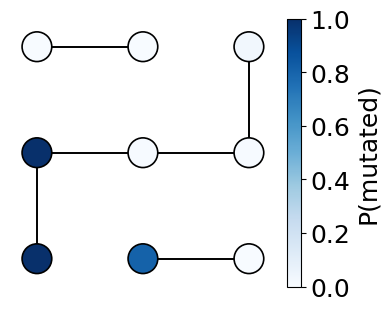

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap, ScalarMappable

# ───────────────────────────  ALPHABET  ─────────────────────────── #
CODE_RBM = [
    "A", "C", "D", "E", "F", "G", "H", "I", "K", "L",
    "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y",
]
aa_to_idx = {a:i for i,a in enumerate(CODE_RBM)}

# ───────────────────────────  LATTICE GEOMETRY  ─────────────────── #
LATTICE = {
    25: (0,  0), 26: (1,  0),  9: (2,  0),
    12: (0, -1), 11: (1, -1), 10: (2, -1),
    13: (0, -2), 16: (1, -2), 17: (2, -2),
}
BONDS = [
    (25, 26),          # top row
    (12, 11), (11, 10),
    (16, 17),
    (12, 13),          # left column
    (9, 10),           # vertical 9 ↔ 10
]
EPITOPE_SITES = list(LATTICE.keys())
sites_idx = np.array(EPITOPE_SITES) - 1  # convert 1-based to 0-based

# ─────────────────  MUTATION PROBABILITY PER (step, site)  ──────────────── #
def mutation_probabilities(
    probas: np.ndarray,                # shape (A, T, S)
    wt_letters: dict[int, str] | None = None  # optional: {site(1-based): 'A', ...}
) -> np.ndarray:
    """
    Returns P(mutated) with shape (T, S):
    mutated means amino acid != reference aa at the first step.
    Reference aa per site:
      - if wt_letters provided, use it
      - else: argmax over amino acids at step 0
    """
    # normalize over amino acids
    denom = probas.sum(axis=0, keepdims=True)    # (1, T, S)
    denom = np.where(denom == 0.0, 1.0, denom)
    p = probas / denom                           # (A, T, S)

    A, T, S = p.shape

    # Build reference index per site (length S)
    ref_idx = np.empty(S, dtype=int)

    if wt_letters is not None:
        # wt_letters keyed by 1-based site index
        for s0 in range(S):
            site_1b = s0 + 1
            if site_1b in wt_letters:
                ref_idx[s0] = aa_to_idx[wt_letters[site_1b]]
            else:
                # fallback to most probable at step 0 if missing
                ref_idx[s0] = int(np.argmax(p[:, 0, s0]))
    else:
        ref_idx = np.argmax(p[:, 0, :], axis=0)  # (S,)

    # P(mutated) = 1 - P(reference aa)
    # gather p_ref[t, s] = p[ref_idx[s], t, s]
    row = ref_idx[np.newaxis, :]                 # (1, S)
    col = np.arange(S)[np.newaxis, :]            # (1, S)
    # for each t, pick p[row, t, col]
    p_ref = p[row, np.arange(T)[:, None], col]   # (T, S)
    p_mut = 1.0 - p_ref
    return p_mut

# ─────────────────────────────  DRAWING  ─────────────────────────── #
def draw_epitope_scalar(
    ax,
    centre=(0.0, 0.0),
    value_map=None,          # dict {site:int -> float} for 9 sites
    edge_colour="black",
    scale=0.35,
    radius=0.14,
    z=3,
    cmap_name="Blues",
    norm=None
):
    """
    Draw 3×3 epitope: bonds + circles colored by provided scalar (no letters).
    """
    cx, cy = centre
    cmap = get_cmap(cmap_name)
    if norm is None:
        vmax = max(value_map.values()) if value_map else 1.0
        norm = Normalize(vmin=0.0, vmax=vmax)

    # bonds
    for a, b in BONDS:
        xa, ya = LATTICE[a]
        xb, yb = LATTICE[b]
        ax.plot(
            [cx + scale*xa, cx + scale*xb],
            [cy + scale*ya, cy + scale*yb],
            lw=1.4, color=edge_colour, zorder=z
        )

    # circles
    for site, (dx, dy) in LATTICE.items():
        v = value_map.get(site, 0.0)
        face = cmap(norm(v))
        circ = Circle(
            (cx + scale*dx, cy + scale*dy),
            radius*scale,
            facecolor=face,
            edgecolor=edge_colour,
            lw=1.2,
            zorder=z+1
        )
        ax.add_patch(circ)

    return norm, cmap

# ─────────────────────────  HIGH-LEVEL PLOTTER  ──────────────────────── #
def plot_epitope_pmut(
    probas: np.ndarray,            # (A, T, S)
    step: int,
    wt_letters: dict[int, str] | None = None,  # optional reference
    cmap_name: str = "Blues"
    #
):
    """
    Plot epitope colored by P(mutated) at a given step.
    If wt_letters is None, reference aa at each site is argmax at step 0.
    """
    p_mut = mutation_probabilities(probas, wt_letters=wt_letters)  # (T, S)

    # restrict to epitope sites
    vals = p_mut[step, sites_idx]                 # shape (9,)
    value_map = {site: v for site, v in zip(EPITOPE_SITES, vals)}

    # figure
    fig, ax = plt.subplots(figsize=(4, 4))
    norm = Normalize(vmin=0.0, vmax=1.0)         # probability in [0, 1]
    norm, cmap = draw_epitope_scalar(
        ax,
        centre=(0.0, 0.0),
        value_map=value_map,
        edge_colour="black",
        scale=0.35,
        radius=0.14,
        z=3,
        cmap_name=cmap_name,
        norm=norm
    )

    # colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("P(mutated)", fontsize=18)
    cbar.ax.tick_params(labelsize=18)           # bigger tick numbers
    ax.set_aspect("equal")
    ax.axis("off")
    # ax.set_title("Mean field")

    plt.tight_layout()
    return fig, ax

# ─────────────────────────────  USAGE  ───────────────────────────── #
# probas = np.load(path_proba)  # shape: (A, T, S)
# Option 1: from most probable aa at step 0
fig, ax = plot_epitope_pmut(probas, step=-1)

# Option 2: provide explicit wild-type letters for sites (1-based indexing)
# wt = {25:"Y", 26:"L", 9:"F", 12:"S", 11:"T", 10:"Q", 13:"N", 16:"V", 17:"I"}
# fig, ax = plot_epitope_pmut(probas, step=5, wt_letters=wt)
# plt.show()
